
--- ZBIÓR: square-simple | ARCHITEKTURA: [1, 32, 1] | AKTYWACJA: RELU | BATCH: 8 | SEED: 42 | GAMMA: 0.9 ---
Czas uczenia: 5.37 s | MSE testowe: 2.6260


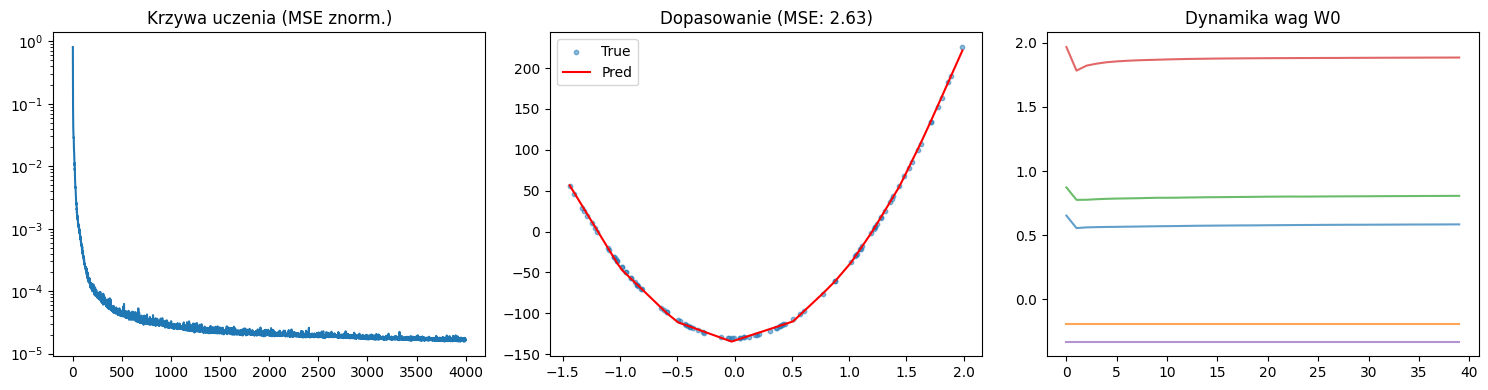


--- ZBIÓR: steps-small | ARCHITEKTURA: [1, 32, 32, 1] | AKTYWACJA: RELU | BATCH: 2 | SEED: 42 | GAMMA: 0.0 ---
Czas uczenia: 53.76 s | MSE testowe: 384.8258


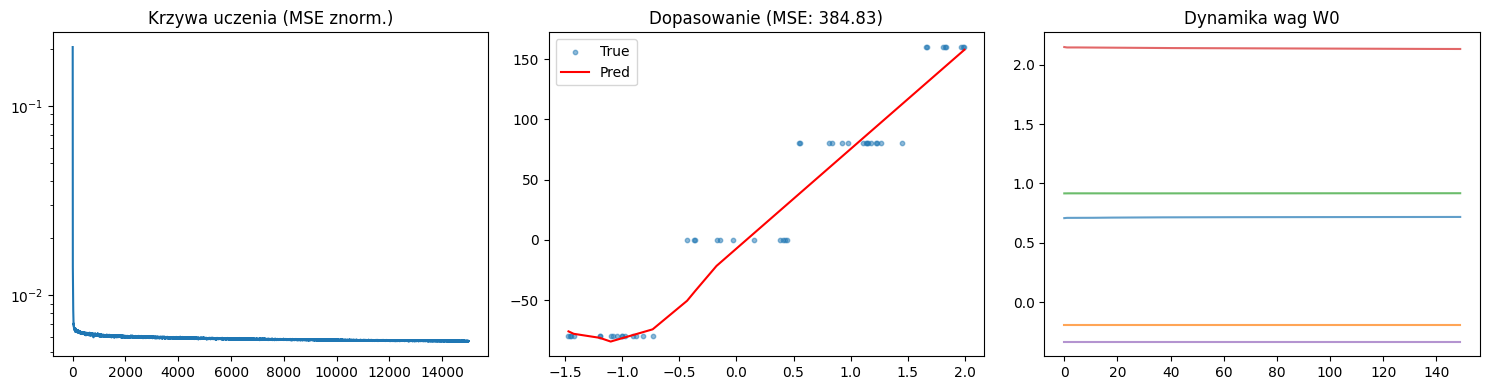


--- ZBIÓR: multimodal-large | ARCHITEKTURA: [1, 64, 64, 1] | AKTYWACJA: RELU | BATCH: 64 | SEED: 42 | GAMMA: 0.9 ---
Czas uczenia: 406.76 s | MSE testowe: 24.8094


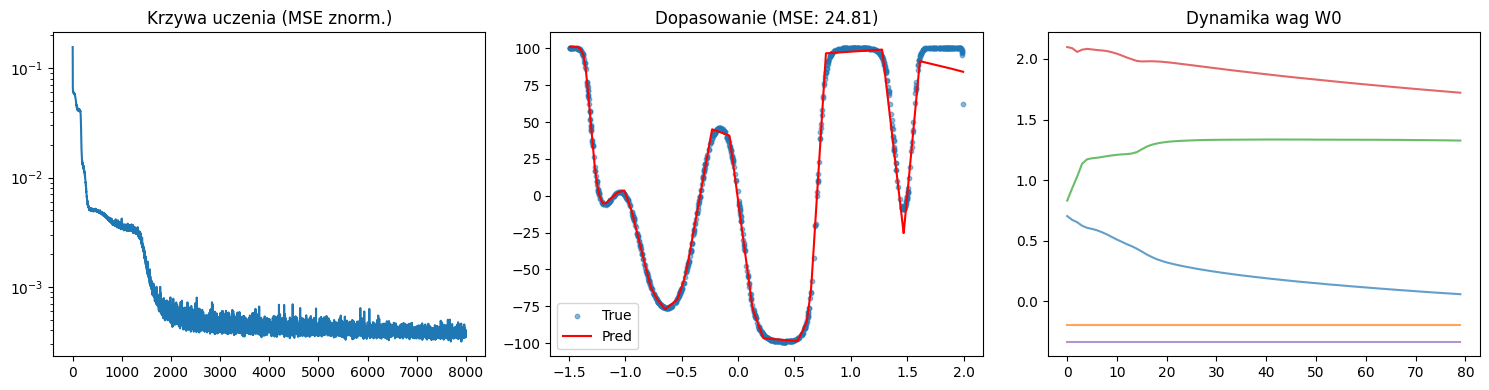

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import time

def wczytaj_csv(sciezka):
    x_lista, y_lista = [], []
    with open(sciezka) as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            x_lista.append(float(row[-2]))
            y_lista.append(float(row[-1]))
    return np.array(x_lista).reshape(-1, 1), np.array(y_lista).reshape(-1, 1)

def sigmoid(z):
    z = np.clip(z, -250, 250)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_deriv(a):
    return a * (1.0 - a)

def relu(z):
    return np.maximum(0, z)

def relu_deriv(a):
    return (a > 0).astype(float)

def tanh(z):
    return np.tanh(z)

def tanh_deriv(a):
    return 1.0 - a**2

class MLP:
    def __init__(self, architektura, activation='relu', init_method=None):
        self.architektura = architektura
        self.act_name = activation
        self.W = []
        self.b = []
        self.vW = []
        self.vb = []
        self.historia_wag = {i: [] for i in range(len(architektura)-1)}

        if init_method is None:
            init_method = 'he' if activation == 'relu' else 'xavier'

        for i in range(len(architektura) - 1):
            if init_method == 'he':
                w = np.random.randn(architektura[i], architektura[i+1]) * np.sqrt(2.0 / architektura[i])
            elif init_method == 'xavier':
                limit = np.sqrt(6 / (architektura[i] + architektura[i+1]))
                w = np.random.uniform(-limit, limit, (architektura[i], architektura[i+1]))
            else:
                w = np.random.randn(architektura[i], architektura[i+1]) * 0.1

            b = np.zeros((1, architektura[i+1]))
            self.W.append(w)
            self.b.append(b)
            self.vW.append(np.zeros_like(w))
            self.vb.append(np.zeros_like(b))

    def _activate(self, Z):
        if self.act_name == 'relu': return relu(Z)
        elif self.act_name == 'sigmoid': return sigmoid(Z)
        elif self.act_name == 'tanh': return tanh(Z)

    def _derive(self, A):
        if self.act_name == 'relu': return relu_deriv(A)
        elif self.act_name == 'sigmoid': return sigmoid_deriv(A)
        elif self.act_name == 'tanh': return tanh_deriv(A)

    def forward(self, X):
        self.A = [X]
        A_curr = X
        for i in range(len(self.W)):
            Z_curr = A_curr @ self.W[i] + self.b[i]
            if i == len(self.W) - 1:
                A_curr = Z_curr
            else:
                A_curr = self._activate(Z_curr)
            self.A.append(A_curr)
        return self.A[-1]

    def backward(self, Y):
        m = Y.shape[0]
        self.dW = [np.zeros_like(w) for w in self.W]
        self.db = [np.zeros_like(b) for b in self.b]

        dZ = self.A[-1] - Y

        for i in reversed(range(len(self.W))):
            self.dW[i] = (self.A[i].T @ dZ) / m
            self.db[i] = np.sum(dZ, axis=0, keepdims=True) / m

            if i > 0:
                dA_prev = dZ @ self.W[i].T
                dZ = dA_prev * self._derive(self.A[i])

    def update_weights(self, lr, gamma=0.9):
        for i in range(len(self.W)):
            self.vW[i] = gamma * self.vW[i] + lr * self.dW[i]
            self.vb[i] = gamma * self.vb[i] + lr * self.db[i]
            self.W[i] -= self.vW[i]
            self.b[i] -= self.vb[i]

    def zapamietaj_wagi(self):
        for i in range(len(self.W)):
            self.historia_wag[i].append(self.W[i].copy().flatten())

    def trenuj(self, X, Y, kroki=10000, lr=0.01, decay=0.0001, batch_size=None, gamma=0.9):
        historia_strat = []
        m = X.shape[0]
        if batch_size is None or batch_size >= m:
            batch_size = m

        for krok in range(kroki):
            current_lr = lr / (1.0 + decay * krok)

            if batch_size < m:
                idx = np.random.permutation(m)
                X_shuffled, Y_shuffled = X[idx], Y[idx]
            else:
                X_shuffled, Y_shuffled = X, Y

            strata_epoch = 0
            batche = 0

            for i in range(0, m, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                Y_batch = Y_shuffled[i:i+batch_size]

                Y_pred = self.forward(X_batch)
                strata_epoch += np.mean((Y_pred - Y_batch) ** 2)
                batche += 1

                self.backward(Y_batch)
                self.update_weights(current_lr, gamma)

            historia_strat.append(strata_epoch / batche)
            if krok % 100 == 0:
                self.zapamietaj_wagi()

        return historia_strat

def uruchom_eksperyment(zbior, architektura, activation, kroki=5000, lr=0.01, decay=0.0001, batch_size=None, seed=42, gamma=0.9):
    np.random.seed(seed)

    print(f"\n--- ZBIÓR: {zbior} | ARCHITEKTURA: {architektura} | AKTYWACJA: {activation.upper()} | BATCH: {batch_size if batch_size else 'Full'} | SEED: {seed} | GAMMA: {gamma} ---")

    x_train, y_train = wczytaj_csv(f"{zbior}-training.csv")
    x_test, y_test = wczytaj_csv(f"{zbior}-test.csv")

    x_min, x_max = x_train.min(), x_train.max()
    y_min, y_max = y_train.min(), y_train.max()

    x_train_n = (x_train - x_min) / (x_max - x_min)
    y_train_n = (y_train - y_min) / (y_max - y_min)
    x_test_n = (x_test - x_min) / (x_max - x_min)

    model = MLP(architektura, activation=activation)

    start_time = time.time()
    historia_strat = model.trenuj(x_train_n, y_train_n, kroki=kroki, lr=lr, decay=decay, batch_size=batch_size, gamma=gamma)
    czas_trwania = time.time() - start_time

    y_pred_n = model.forward(x_test_n)
    y_pred = y_pred_n * (y_max - y_min) + y_min
    mse_test = np.mean((y_test - y_pred) ** 2)

    print(f"Czas uczenia: {czas_trwania:.2f} s | MSE testowe: {mse_test:.4f}")

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(historia_strat)
    plt.title("Krzywa uczenia (MSE znorm.)")
    plt.yscale('log')

    idx = np.argsort(x_test.flatten())
    plt.subplot(1, 3, 2)
    plt.scatter(x_test, y_test, s=10, alpha=0.5, label='True')
    plt.plot(x_test[idx], y_pred[idx], color='red', label='Pred')
    plt.title(f"Dopasowanie (MSE: {mse_test:.2f})")
    plt.legend()

    plt.subplot(1, 3, 3)
    hist_w0 = np.array(model.historia_wag[0])
    for j in range(min(5, hist_w0.shape[1])):
        plt.plot(hist_w0[:, j], alpha=0.7)
    plt.title("Dynamika wag W0")

    plt.tight_layout()
    plt.show()

    return mse_test

# --- EKSPERYMENTY ---

# Square-simple
_ = uruchom_eksperyment("square-simple", [1, 32, 1], activation='relu', kroki=4000, lr=0.04, decay=0.0008, batch_size=8, seed=42)

# Steps-small (Wyłączone momentum gamma=0.0, uspokojony batch i LR)
_ = uruchom_eksperyment("steps-small", [1, 32, 32, 1], activation='relu', kroki=15000, lr=0.003, decay=0.0001, batch_size=2, seed=42, gamma=0.0)

# Multimodal-large (Jeśli seed 42 nie daje MSE < 40, przetestuj np. 123, 777, etc.)
_ = uruchom_eksperyment("multimodal-large", [1, 64, 64, 1], activation='relu', kroki=8000, lr=0.01, decay=0.00000, batch_size=64, seed=42)

In [ ]:
# Square-simple
_ = uruchom_eksperyment("square-simple", [1, 32, 1], activation='relu', kroki=4000, lr=0.04, decay=0.0008, batch_size=8, seed=42)

# Steps-small (Wyłączone momentum gamma=0.0, uspokojony batch i LR)
_ = uruchom_eksperyment("steps-small", [1, 32, 32, 1], activation='relu', kroki=15000, lr=0.003, decay=0.0001, batch_size=2, seed=42, gamma=0.0)


# Multimodal-large
_ = uruchom_eksperyment("multimodal-large", [1, 64, 64, 1], activation='relu', kroki=8000, lr=0.01, decay=0.00000, batch_size=None, seed=42)


--- ZBIÓR: steps-small | ARCHITEKTURA: [1, 16, 16, 1] | AKTYWACJA: RELU | BATCH: Full | SEED: 42 | GAMMA: 0.9 ---
Czas uczenia: 4.89 s | MSE testowe: 161.2039


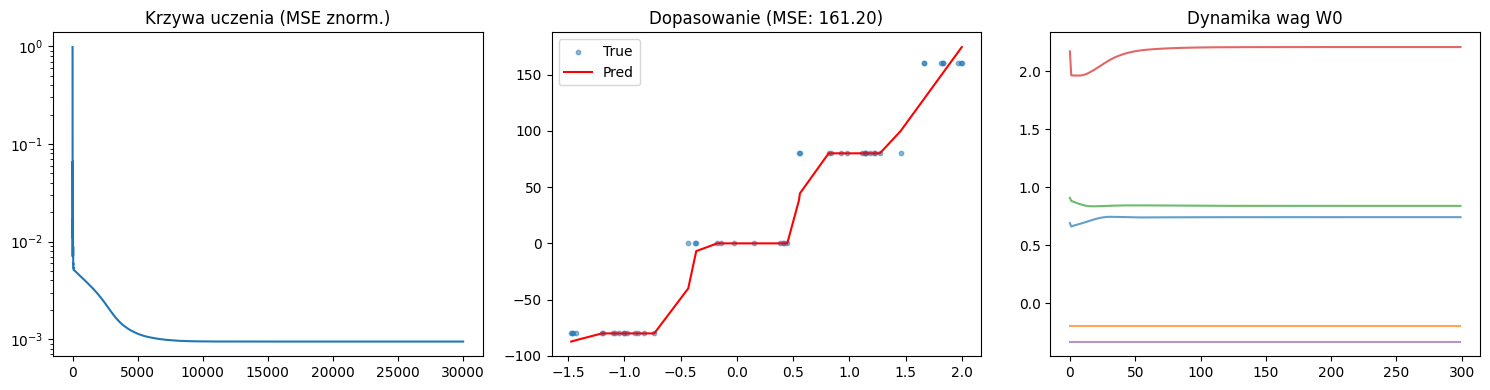


--- ZBIÓR: steps-small | ARCHITEKTURA: [1, 16, 16, 1] | AKTYWACJA: RELU | BATCH: 64 | SEED: 42 | GAMMA: 0.9 ---
Czas uczenia: 1.23 s | MSE testowe: 160.6092


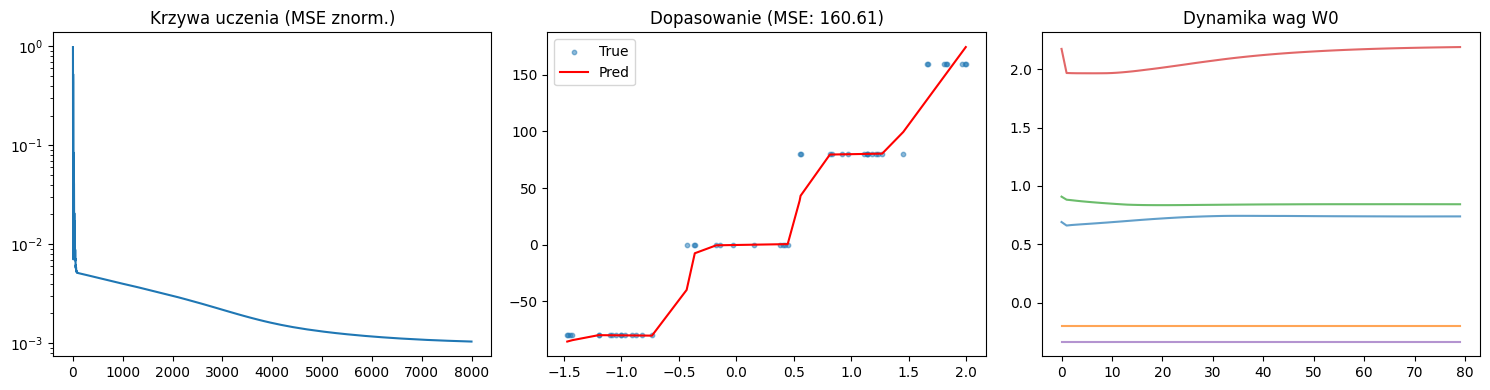


--- ZBIÓR: steps-small | ARCHITEKTURA: [1, 16, 16, 1] | AKTYWACJA: RELU | BATCH: 2 | SEED: 42 | GAMMA: 0.9 ---
Czas uczenia: 10.66 s | MSE testowe: 413.9542


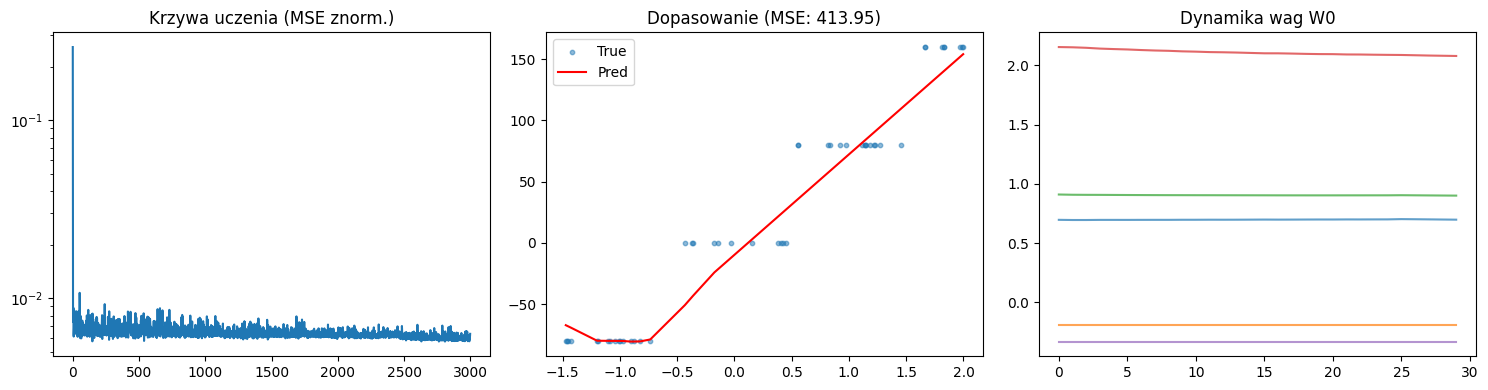

In [30]:



# steps small
_ = uruchom_eksperyment("steps-small", [1, 16, 16, 1], activation='relu', kroki=30000, lr=0.1, decay=0.00001, batch_size=None, seed=42, gamma=0.9)

_ = uruchom_eksperyment("steps-small", [1, 16, 16, 1], activation='relu', kroki=8000, lr=0.1, decay=0.0001, batch_size=64, seed=42, gamma=0.9)

_ = uruchom_eksperyment("steps-small", [1, 16, 16, 1], activation='relu', kroki=3000, lr=0.003, decay=0.00001, batch_size=2, seed=42, gamma=0.9)

